# 23. 피처 엔지니어링

## 개요

추천 시스템 학습을 위한 피처 엔지니어링 및 상호작용 행렬 생성.

**학술적 근거**:
- Hu, Y., Koren, Y., & Volinsky, C. (2008). IEEE ICDM
  → Implicit Feedback을 위한 Confidence Weighting
- Netflix Prize (2009): 가중치 최적화 기법

**주요 단계**:
1. 상호작용 가중치 적용 (view=0.1, cart=2.0, order=5.0)
2. Confidence Weighting: C = 1 + α × log(1 + r)
3. 희소 행렬 (CSR) 생성
4. 학습/테스트 분할

**출력**:
- `data/instacart/interaction_matrix.npz`
- `data/instacart/user_mapping.json`
- `data/instacart/item_mapping.json`

## 1. 환경 설정

In [1]:
import os
import sys
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from scipy import sparse
from scipy.sparse import csr_matrix, save_npz, load_npz

# 프로젝트 경로
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / 'notebooks'))

from utils.personalization import (
    InteractionMatrixBuilder,
    FeatureEngineer,
    INTERACTION_WEIGHTS,
    CONFIDENCE_WEIGHTS,
    compute_confidence,
)

DATA_PATH = PROJECT_ROOT / 'data' / 'instacart'

print(f"프로젝트 루트: {PROJECT_ROOT}")
print(f"데이터 경로: {DATA_PATH}")

프로젝트 루트: d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone
데이터 경로: d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\data\instacart


## 2. 데이터 로드

In [2]:
%%time

# 데이터 로드
orders_df = pd.read_parquet(DATA_PATH / 'orders.parquet')
order_products_df = pd.read_parquet(DATA_PATH / 'order_products.parquet')
products_df = pd.read_parquet(DATA_PATH / 'mapped_products.parquet')

print(f"주문 수: {len(orders_df):,}")
print(f"주문-상품 관계: {len(order_products_df):,}")
print(f"상품 수: {len(products_df):,}")

주문 수: 3,421,083
주문-상품 관계: 33,819,106
상품 수: 49,688
CPU times: total: 922 ms
Wall time: 223 ms


## 3. 상호작용 가중치 설정

In [3]:
# 상호작용 가중치 확인 (전환율 역산 기반)
print("상호작용 가중치 (Interaction Weights):")
print(f"  - view: {INTERACTION_WEIGHTS.view} (97% 노이즈)")
print(f"  - wishlist: {INTERACTION_WEIGHTS.wishlist}")
print(f"  - cart: {INTERACTION_WEIGHTS.cart} (25% 전환)")
print(f"  - review: {INTERACTION_WEIGHTS.review}")
print(f"  - order: {INTERACTION_WEIGHTS.order} (기준점)")

print("\nConfidence Weighting 설정:")
print(f"  - alpha: {CONFIDENCE_WEIGHTS.alpha}")
print(f"  - epsilon: {CONFIDENCE_WEIGHTS.epsilon}")
print(f"  - use_log: {CONFIDENCE_WEIGHTS.use_log}")

상호작용 가중치 (Interaction Weights):
  - view: 0.1 (97% 노이즈)
  - wishlist: 0.5
  - cart: 2.0 (25% 전환)
  - review: 4.0
  - order: 5.0 (기준점)

Confidence Weighting 설정:
  - alpha: 15.0
  - epsilon: 0.0
  - use_log: True


In [4]:
# Instacart 데이터는 실제 구매 데이터이므로 order 가중치 적용
# Implicit Feedback: 구매 = 관심 (r_ui > 0)

# 사용자-상품 조인
user_product_df = order_products_df.merge(
    orders_df[['order_id', 'user_id', 'order_number', 'days_since_prior_order']],
    on='order_id'
)

print(f"사용자-상품 상호작용: {len(user_product_df):,}")
print(f"고유 사용자: {user_product_df['user_id'].nunique():,}")
print(f"고유 상품: {user_product_df['product_id'].nunique():,}")

사용자-상품 상호작용: 33,819,106
고유 사용자: 206,209
고유 상품: 49,685


## 4. 상호작용 점수 계산

In [5]:
# 사용자-상품별 구매 횟수 집계
interaction_counts = user_product_df.groupby(['user_id', 'product_id']).agg({
    'order_id': 'count',  # 구매 횟수
    'reordered': 'sum',   # 재구매 횟수
    'add_to_cart_order': 'mean',  # 평균 장바구니 순서
}).reset_index()

interaction_counts.columns = ['user_id', 'product_id', 'purchase_count', 'reorder_count', 'avg_cart_order']

print(f"고유 사용자-상품 쌍: {len(interaction_counts):,}")
interaction_counts.head(10)

고유 사용자-상품 쌍: 13,863,746


,user_id,product_id,purchase_count,reorder_count,avg_cart_order
0,1,196,11,10,1.363636
1,1,10258,10,9,3.600000
2,1,10326,1,0,5.000000
3,1,12427,10,9,3.300000
4,1,13032,4,3,6.500000
5,1,13176,2,1,6.000000
6,1,14084,1,0,2.000000
7,1,17122,1,0,6.000000
8,1,25133,9,8,3.777778
9,1,26088,3,2,5.666667


In [6]:
# 상호작용 점수 계산
# r_ui = purchase_count × order_weight
ORDER_WEIGHT = INTERACTION_WEIGHTS.order

interaction_counts['raw_score'] = interaction_counts['purchase_count'] * ORDER_WEIGHT

# 재구매 보너스 (충성 고객 보상)
REORDER_BONUS = 1.2  # 재구매시 20% 보너스
interaction_counts['reorder_bonus'] = np.where(
    interaction_counts['reorder_count'] > 0,
    REORDER_BONUS,
    1.0
)

interaction_counts['final_score'] = interaction_counts['raw_score'] * interaction_counts['reorder_bonus']

print("상호작용 점수 통계:")
print(interaction_counts['final_score'].describe())

상호작용 점수 통계:
count    1.386375e+07
mean     1.403772e+01
std      2.153707e+01
min      5.000000e+00
25%      5.000000e+00
50%      5.000000e+00
75%      1.200000e+01
max      6.000000e+02
Name: final_score, dtype: float64


## 5. Confidence Weighting

Confidence 통계:
count    1.386375e+07
mean     3.574028e+01
std      1.128432e+01
min      2.787639e+01
25%      2.787639e+01
50%      2.787639e+01
75%      3.947424e+01
max      9.697892e+01
Name: confidence, dtype: float64


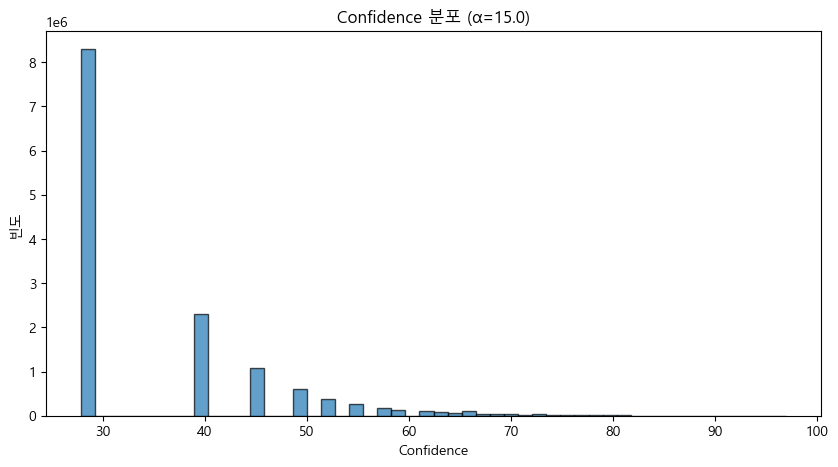

In [7]:
# Confidence Weighting 적용 (Hu et al., 2008)
# C_ui = 1 + α × log(1 + r_ui)

ALPHA = CONFIDENCE_WEIGHTS.alpha  # 15.0 권장

interaction_counts['confidence'] = interaction_counts['final_score'].apply(
    lambda r: compute_confidence(r)
)

print("Confidence 통계:")
print(interaction_counts['confidence'].describe())

# Confidence 분포 시각화
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(interaction_counts['confidence'], bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Confidence')
ax.set_ylabel('빈도')
ax.set_title(f'Confidence 분포 (α={ALPHA})')
plt.show()

## 6. ID 매핑 생성

In [8]:
# 연속 인덱스 매핑 생성
# 희소 행렬 효율성을 위해 ID를 0부터 시작하는 연속 인덱스로 변환

unique_users = interaction_counts['user_id'].unique()
unique_products = interaction_counts['product_id'].unique()

user_id_to_idx = {uid: idx for idx, uid in enumerate(unique_users)}
idx_to_user_id = {idx: uid for uid, idx in user_id_to_idx.items()}

product_id_to_idx = {pid: idx for idx, pid in enumerate(unique_products)}
idx_to_product_id = {idx: pid for pid, idx in product_id_to_idx.items()}

n_users = len(unique_users)
n_products = len(unique_products)

print(f"사용자 수: {n_users:,}")
print(f"상품 수: {n_products:,}")
print(f"행렬 크기: {n_users:,} × {n_products:,} = {n_users * n_products:,}")

사용자 수: 206,209
상품 수: 49,685
행렬 크기: 206,209 × 49,685 = 10,245,494,165


In [9]:
# 인덱스 적용
interaction_counts['user_idx'] = interaction_counts['user_id'].map(user_id_to_idx)
interaction_counts['product_idx'] = interaction_counts['product_id'].map(product_id_to_idx)

print("인덱스 매핑 완료")
interaction_counts[['user_id', 'user_idx', 'product_id', 'product_idx', 'confidence']].head(10)

인덱스 매핑 완료


,user_id,user_idx,product_id,product_idx,confidence
0,1,0,196,0,64.070389
1,1,0,10258,1,62.663108
2,1,0,10326,2,27.876392
3,1,0,12427,3,62.663108
4,1,0,13032,4,49.283137
5,1,0,13176,5,39.474240
6,1,0,14084,6,27.876392
7,1,0,17122,7,27.876392
8,1,0,25133,8,61.109998
9,1,0,26088,9,45.166585


## 7. 희소 행렬 (CSR) 생성

In [10]:
%%time

# CSR 희소 행렬 생성
# 값 = Confidence

rows = interaction_counts['user_idx'].values
cols = interaction_counts['product_idx'].values
values = interaction_counts['confidence'].values.astype(np.float32)

interaction_matrix = csr_matrix(
    (values, (rows, cols)),
    shape=(n_users, n_products),
    dtype=np.float32
)

print(f"희소 행렬 생성 완료")
print(f"  - 형태: {interaction_matrix.shape}")
print(f"  - 비영 요소: {interaction_matrix.nnz:,}")
print(f"  - 희소성: {1 - interaction_matrix.nnz / (n_users * n_products):.6f}")
print(f"  - 밀도: {interaction_matrix.nnz / (n_users * n_products) * 100:.4f}%")
print(f"  - 메모리: {(interaction_matrix.data.nbytes + interaction_matrix.indices.nbytes + interaction_matrix.indptr.nbytes) / 1024**2:.1f} MB")

희소 행렬 생성 완료
  - 형태: (206209, 49685)
  - 비영 요소: 13,863,746
  - 희소성: 0.998647
  - 밀도: 0.1353%
  - 메모리: 106.6 MB
CPU times: total: 328 ms
Wall time: 324 ms


In [11]:
# Binary 행렬도 생성 (0/1)
# ALS에서 preference 행렬로 사용

binary_matrix = (interaction_matrix > 0).astype(np.float32)

print(f"Binary 행렬 생성 완료")
print(f"  - 비영 요소 (상호작용 수): {binary_matrix.nnz:,}")

Binary 행렬 생성 완료
  - 비영 요소 (상호작용 수): 13,863,746


## 8. 학습/테스트 분할

In [12]:
# 시간 기반 분할 (마지막 주문을 테스트로)
# eval_set = 'train'인 주문을 테스트로 사용

train_orders = orders_df[orders_df['eval_set'] == 'prior']['order_id'].unique()
test_orders = orders_df[orders_df['eval_set'] == 'train']['order_id'].unique()

print(f"학습 주문 수: {len(train_orders):,}")
print(f"테스트 주문 수: {len(test_orders):,}")

학습 주문 수: 3,214,874
테스트 주문 수: 131,209


In [13]:
# 테스트 세트 생성
# 테스트 = 각 사용자의 마지막 주문에서 구매한 상품

test_order_products = order_products_df[
    order_products_df['order_id'].isin(test_orders)
].merge(
    orders_df[['order_id', 'user_id']], on='order_id'
)

# 사용자별 테스트 상품 집합
test_data = test_order_products.groupby('user_id')['product_id'].apply(set).to_dict()

# 인덱스로 변환
test_data_indexed = {}
for user_id, products in test_data.items():
    if user_id in user_id_to_idx:
        user_idx = user_id_to_idx[user_id]
        product_idxs = {product_id_to_idx[p] for p in products if p in product_id_to_idx}
        if product_idxs:
            test_data_indexed[user_idx] = product_idxs

print(f"테스트 사용자 수: {len(test_data_indexed):,}")

테스트 사용자 수: 131,209


In [14]:
# 학습 행렬 (테스트 상호작용 제외)
# 간단히 prior 주문만 사용

train_order_products = order_products_df[
    order_products_df['order_id'].isin(train_orders)
].merge(
    orders_df[['order_id', 'user_id']], on='order_id'
)

train_interactions = train_order_products.groupby(['user_id', 'product_id']).size().reset_index(name='count')

# 인덱스 변환
train_interactions['user_idx'] = train_interactions['user_id'].map(user_id_to_idx)
train_interactions['product_idx'] = train_interactions['product_id'].map(product_id_to_idx)

# 누락된 매핑 제거
train_interactions = train_interactions.dropna(subset=['user_idx', 'product_idx'])
train_interactions['user_idx'] = train_interactions['user_idx'].astype(int)
train_interactions['product_idx'] = train_interactions['product_idx'].astype(int)

# Confidence 계산
train_interactions['confidence'] = train_interactions['count'].apply(
    lambda c: compute_confidence(c * ORDER_WEIGHT)
)

print(f"학습 상호작용: {len(train_interactions):,}")

학습 상호작용: 13,307,953


In [15]:
# 학습용 희소 행렬
train_matrix = csr_matrix(
    (train_interactions['confidence'].values.astype(np.float32),
     (train_interactions['user_idx'].values, train_interactions['product_idx'].values)),
    shape=(n_users, n_products),
    dtype=np.float32
)

print(f"학습 행렬")
print(f"  - 형태: {train_matrix.shape}")
print(f"  - 비영 요소: {train_matrix.nnz:,}")

학습 행렬
  - 형태: (206209, 49685)
  - 비영 요소: 13,307,953


## 9. 추가 피처 생성

In [16]:
# 상품별 인기도 (추천 다양성 및 신규성 평가용)
product_popularity = interaction_counts.groupby('product_id')['purchase_count'].sum()
product_popularity = product_popularity / product_popularity.sum()  # 정규화

print("상품 인기도 통계:")
print(product_popularity.describe())

상품 인기도 통계:
count    4.968500e+04
mean     2.012680e-05
std      1.474838e-04
min      2.956908e-08
25%      5.322435e-07
50%      1.862852e-06
75%      8.042791e-06
max      1.452703e-02
Name: purchase_count, dtype: float64


In [17]:
# 사용자별 상호작용 수 (하이브리드 가중치용)
user_interaction_counts = interaction_counts.groupby('user_id').size()

print("사용자별 상호작용 수 통계:")
print(user_interaction_counts.describe())

사용자별 상호작용 수 통계:
count    206209.000000
mean         67.231527
std          56.876842
min           1.000000
25%          28.000000
50%          51.000000
75%          89.000000
max         728.000000
dtype: float64


In [18]:
# 카테고리별 인기 상품
product_with_category = interaction_counts.merge(
    products_df[['product_id', 'self_category']], on='product_id'
)

category_popular = product_with_category.groupby('self_category').apply(
    lambda x: x.nlargest(100, 'purchase_count')['product_id'].tolist()
).to_dict()

print("카테고리별 인기 상품 수:")
for cat, products in category_popular.items():
    print(f"  {cat}: {len(products)}")

카테고리별 인기 상품 수:
  견과/건과/간식: 100
  과일/견과: 100
  기타: 100
  김치/반찬/절임: 100
  두부/콩/계란: 100
  라면/간편식품/통조림: 100
  면/가루/베이커리/제빵: 100
  수산물/해산물/건어물: 100
  쌀/잡곡: 100
  양념/조미/소스/오일: 100
  우유/유제품: 100
  육류: 100
  음료: 100
  채소/샐러드/버섯/나물: 100


## 10. 데이터 저장

In [19]:
%%time

# 희소 행렬 저장
save_npz(DATA_PATH / 'interaction_matrix.npz', interaction_matrix)
save_npz(DATA_PATH / 'train_matrix.npz', train_matrix)

print("희소 행렬 저장 완료")
print(f"  - interaction_matrix.npz")
print(f"  - train_matrix.npz")

희소 행렬 저장 완료
  - interaction_matrix.npz
  - train_matrix.npz
CPU times: total: 12 s
Wall time: 12 s


In [20]:
# ID 매핑 저장
user_mapping = {
    'user_id_to_idx': {int(k): int(v) for k, v in user_id_to_idx.items()},
    'idx_to_user_id': {int(k): int(v) for k, v in idx_to_user_id.items()},
}

item_mapping = {
    'product_id_to_idx': {int(k): int(v) for k, v in product_id_to_idx.items()},
    'idx_to_product_id': {int(k): int(v) for k, v in idx_to_product_id.items()},
}

with open(DATA_PATH / 'user_mapping.json', 'w') as f:
    json.dump(user_mapping, f)

with open(DATA_PATH / 'item_mapping.json', 'w') as f:
    json.dump(item_mapping, f)

print("ID 매핑 저장 완료")

ID 매핑 저장 완료


In [21]:
# 테스트 데이터 저장
test_data_serializable = {
    str(k): list(v) for k, v in test_data_indexed.items()
}

with open(DATA_PATH / 'test_data.json', 'w') as f:
    json.dump(test_data_serializable, f)

print(f"테스트 데이터 저장 완료: {len(test_data_indexed)} 사용자")

테스트 데이터 저장 완료: 131209 사용자


In [22]:
# 추가 피처 저장
features = {
    'product_popularity': {int(k): float(v) for k, v in product_popularity.items()},
    'user_interaction_counts': {int(k): int(v) for k, v in user_interaction_counts.items()},
    'category_popular_products': category_popular,
}

with open(DATA_PATH / 'features.json', 'w', encoding='utf-8') as f:
    json.dump(features, f, ensure_ascii=False, indent=2)

print("추가 피처 저장 완료: features.json")

추가 피처 저장 완료: features.json


In [23]:
# 메타데이터 저장
metadata = {
    'created_at': datetime.now().isoformat(),
    'n_users': n_users,
    'n_products': n_products,
    'n_interactions': int(interaction_matrix.nnz),
    'sparsity': float(1 - interaction_matrix.nnz / (n_users * n_products)),
    'n_train_interactions': int(train_matrix.nnz),
    'n_test_users': len(test_data_indexed),
    'hyperparameters': {
        'order_weight': ORDER_WEIGHT,
        'alpha': float(ALPHA),
        'reorder_bonus': REORDER_BONUS,
    },
}

with open(DATA_PATH / 'feature_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("메타데이터 저장 완료: feature_metadata.json")

메타데이터 저장 완료: feature_metadata.json


## 11. 요약

In [24]:
summary = f"""
==========================================
피처 엔지니어링 완료
==========================================

1. 상호작용 행렬
   - 크기: {n_users:,} × {n_products:,}
   - 상호작용: {interaction_matrix.nnz:,}
   - 희소성: {1 - interaction_matrix.nnz / (n_users * n_products):.4%}

2. 가중치 설정
   - Order Weight: {ORDER_WEIGHT}
   - Confidence α: {ALPHA}
   - Reorder Bonus: {REORDER_BONUS}

3. 학습/테스트 분할
   - 학습 상호작용: {train_matrix.nnz:,}
   - 테스트 사용자: {len(test_data_indexed):,}

4. 생성된 파일
   - interaction_matrix.npz
   - train_matrix.npz
   - user_mapping.json
   - item_mapping.json
   - test_data.json
   - features.json
   - feature_metadata.json

==========================================
"""

print(summary)


피처 엔지니어링 완료

1. 상호작용 행렬
   - 크기: 206,209 × 49,685
   - 상호작용: 13,863,746
   - 희소성: 99.8647%

2. 가중치 설정
   - Order Weight: 5.0
   - Confidence α: 15.0
   - Reorder Bonus: 1.2

3. 학습/테스트 분할
   - 학습 상호작용: 13,307,953
   - 테스트 사용자: 131,209

4. 생성된 파일
   - interaction_matrix.npz
   - train_matrix.npz
   - user_mapping.json
   - item_mapping.json
   - test_data.json
   - features.json
   - feature_metadata.json




## 다음 단계

- **24_als_model_training.ipynb**: ALS 32차원 모델 학습
  - ALS 모델 학습 (implicit 라이브러리)
  - 하이퍼파라미터 튜닝
  - 사용자/아이템 임베딩 추출